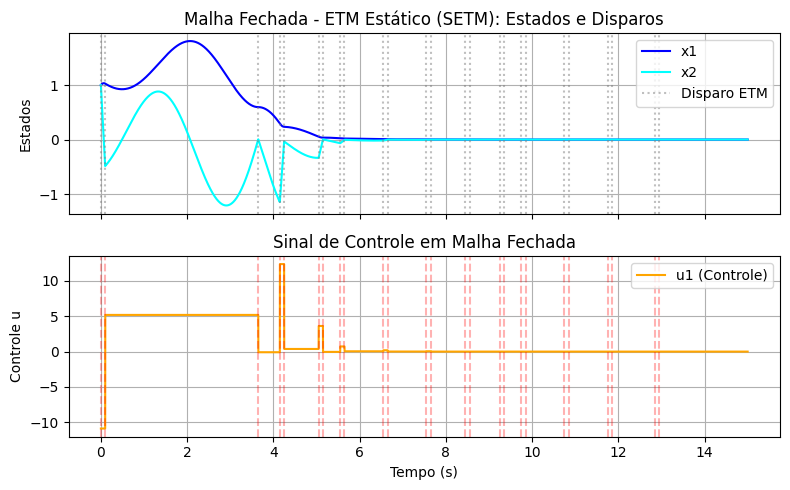

In [11]:
import matplotlib.pyplot as plt
import numpy as np


def load_signal(filepath):
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-closed-loop-setm'

time = load_signal(f'{dir_path}/time.bin')
x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
u1 = load_signal(f'{dir_path}/u1.bin')
trigger_times = load_signal(f'{dir_path}/trigger_times.bin')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Gráfico dos Estados e Instantes de Disparo
ax1.plot(time, x1, label='x1', color='blue')
ax1.plot(time, x2, label='x2', color='cyan')
for i, t_trig in enumerate(trigger_times):
  label_val = 'Disparo ETM' if i == 0 else ''
  ax1.axvline(t_trig, color='gray', linestyle=':', alpha=0.5, label=label_val)

ax1.set_title('Malha Fechada - ETM Estático (SETM): Estados e Disparos')
ax1.set_ylabel('Estados')
ax1.legend()
ax1.grid(True)

# Gráfico do Sinal de Controle (ZOH) com marcação de disparos
ax2.plot(time, u1, label='u1 (Controle)', color='orange')
for t_trig in trigger_times:
  ax2.axvline(t_trig, color='red', linestyle='--', alpha=0.3)

ax2.set_title('Sinal de Controle em Malha Fechada')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Controle u')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
x1[-1]

np.float64(-8.282856939814156e-07)